In [13]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import fractional_matrix_power
from psyduck import Spin
from psyduck.operations import *
from psyduck.hamiltonians import zeeman_hamiltonian, hyperfine_hamiltonian
from psyduck.plotting import plot_transition_matrix_simplified
from psyduck.plotting.readout_plot import plot_transition_matrix, plot_transition_matrix_simplified

# Build Hamiltonian model

In [4]:
nucleus = Spin(I=7/2)
Ix, Iy, Iz = nucleus.get_spin_operators()

electron = Spin(I=1/2)
Sx, Sy, Sz = electron.get_spin_operators()

In [48]:
H_quad = qt.Qobj(np.load('../quadrupole modeling/H_quad_fit.npy')) # from fit
# H_quad_neutral = np.load('../quadrupole modeling/H_quad_neutral.npy') # from fit
Hz_nucleus = zeeman_hamiltonian(7/2, B0=1.4, gamma=5.55)
Hz_electron = zeeman_hamiltonian(1/2, B0=1.4, gamma=28.8e3)
H_ionized = - Hz_nucleus + H_quad
H_hyperfine = hyperfine_hamiltonian(S=1/2, I=7/2, A=97.5)
H_neutral = qt.tensor(Hz_electron, qt.qeye(8)) + qt.tensor(qt.qeye(2), H_ionized) - H_hyperfine

In [49]:
P_donor = qt.tensor(qt.Qobj(np.array([[1, 0], [0, 1], [0, 0]])), qt.qeye(8))
P_SET = qt.tensor(qt.Qobj(np.array([0, 0, 1])), qt.qeye(8))

H_neutral_full = qt.Qobj(P_donor.full() @ H_neutral.full() @ P_donor.dag().full())
H_ionized_full = qt.Qobj(P_SET.full() @ H_ionized.full() @ P_SET.dag().full())
H_full = H_neutral_full + H_ionized_full

## Visualize Hamiltonian

Text(0, 0.5, 'Row Index')

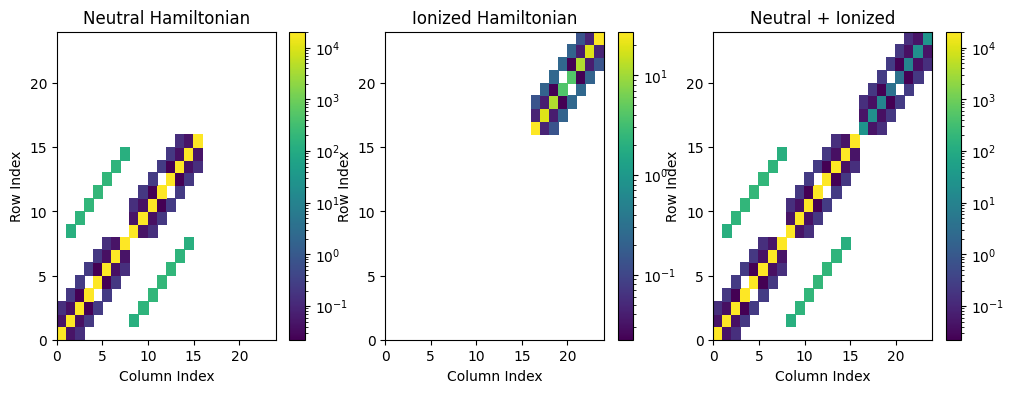

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
pcm1 = ax[0].pcolor(np.abs(H_neutral_full.full()), norm=LogNorm())
pcm2 = ax[1].pcolor(np.abs(H_ionized_full.full()), norm=LogNorm())
pcm3 = ax[2].pcolor(np.abs(H_full.full()), norm=LogNorm())
plt.colorbar(pcm1, ax=ax[0])
plt.colorbar(pcm2, ax=ax[1])
plt.colorbar(pcm3, ax=ax[2])
ax[0].set_title('Neutral Hamiltonian')
ax[1].set_title('Ionized Hamiltonian')
ax[2].set_title('Neutral + Ionized')

ax[0].set_xlabel('Column Index')
ax[0].set_ylabel('Row Index')
ax[1].set_xlabel('Column Index')
ax[1].set_ylabel('Row Index')
ax[2].set_xlabel('Column Index')
ax[2].set_ylabel('Row Index')

## compute eigenvalues and eigenvectors

In [51]:
(eigenvalues_full, eigenstates_full) = H_full.eigenstates()
eigenstate_full_matrix = np.zeros([24,24], dtype=complex)
for i in range(24):
    idx_argmax = np.argmax(np.abs(eigenstates_full[i].full().flatten())**2)
    eigenstate_full_matrix[idx_argmax] = eigenstates_full[i].full().flatten()

<Axes: >

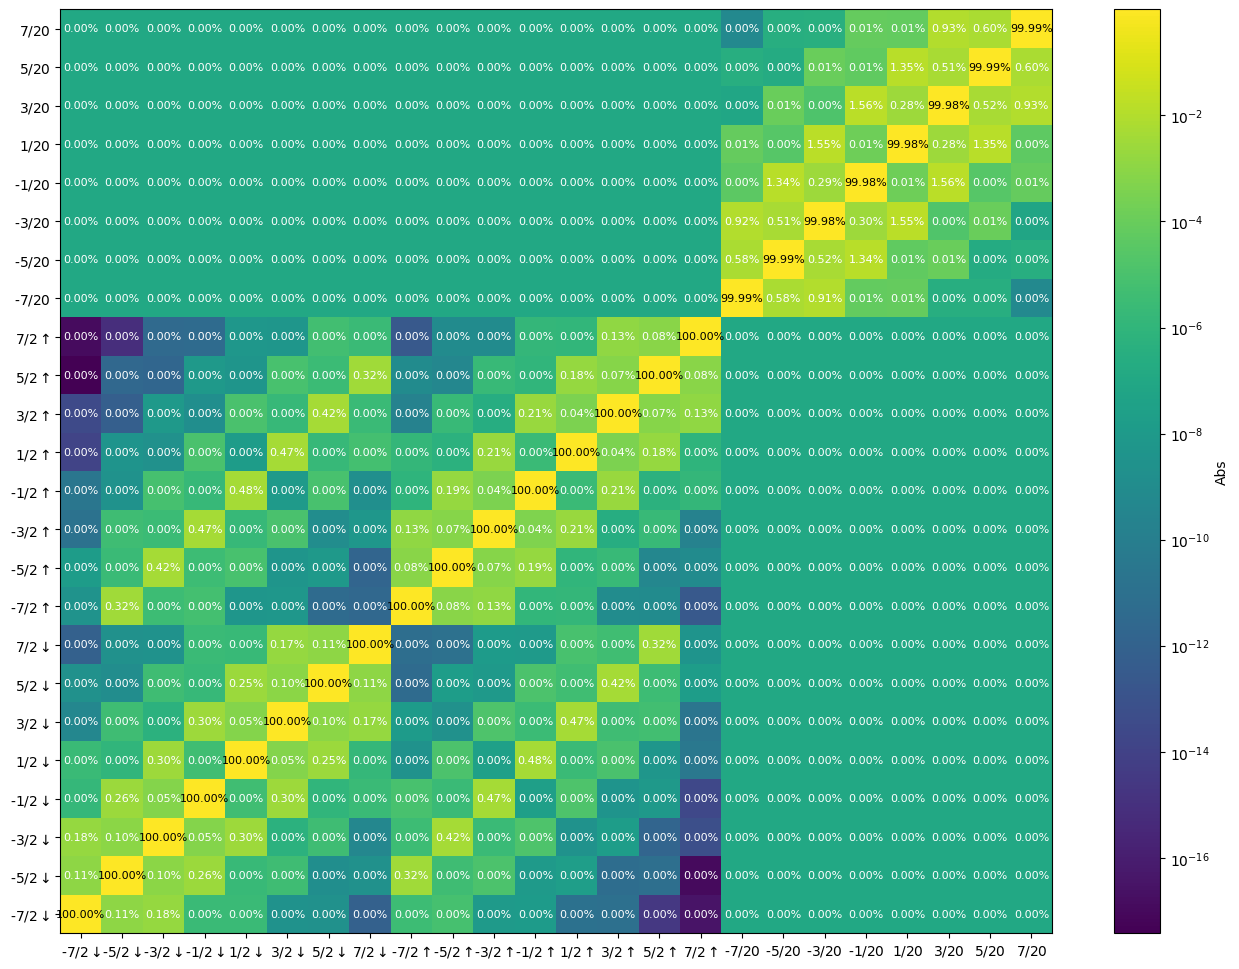

In [52]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
plot_transition_matrix(eigenstate_full_matrix, electron_states=3, ax=ax)

In [53]:
nmr_freqs = np.zeros(7)
for i in range(len(nmr_freqs)):
    nmr_freqs[i] = eigenvalues_full[8+i] - eigenvalues_full[8+i+1]

ESR_freqs = np.diff(np.abs(eigenvalues_full[:8] - eigenvalues_full[16:][::-1]))

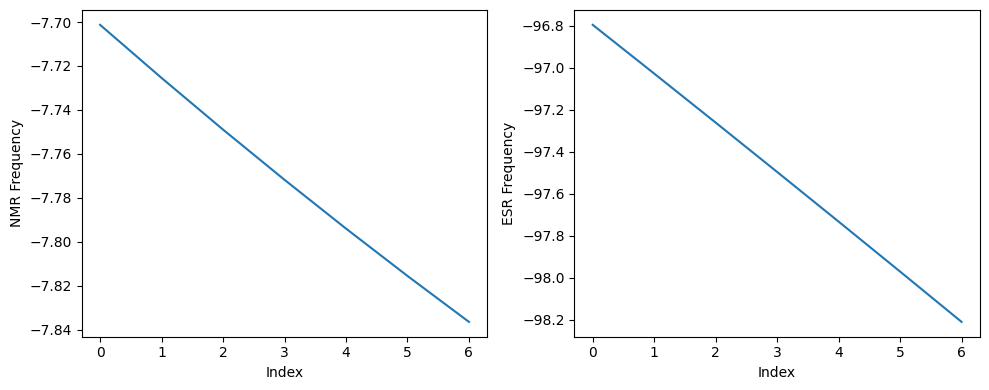

In [54]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(nmr_freqs)
ax[0].set_xlabel('Index')
ax[0].set_ylabel('NMR Frequency')
ax[1].plot(ESR_freqs)
ax[1].set_xlabel('Index')
ax[1].set_ylabel('ESR Frequency')
plt.tight_layout()

# Calculate ionization shock

In [55]:
# Compute transition probabilities via direct projection
transition_matrix_ionize_up = np.zeros((8, 8))
transition_matrix_ionize_down = np.zeros((8, 8))
transition_matrix_neutralize_down = np.zeros((8,8))
transition_matrix_neutralize_up = np.zeros((8,8))

for i in range(8):  # Neutral states
    for j in range(8):  # Ionized states

        transition_matrix_ionize_up[i, j] = np.abs(
            np.dot(eigenstate_full_matrix[8+i, 8:16].conj().T, eigenstate_full_matrix[16 + j, 16:])
        )**2 + np.dot(eigenstate_full_matrix[8+i, :8].conj().T, eigenstate_full_matrix[16 + j, 16:])**2

        transition_matrix_ionize_down[i, j] = np.abs(
            np.dot(eigenstate_full_matrix[i, :8].conj().T, eigenstate_full_matrix[16 + j, 16:])
        )**2 + np.dot(eigenstate_full_matrix[i, 8:16].conj().T, eigenstate_full_matrix[16 + j, 16:])**2

transition_matrix_neutralize_up = transition_matrix_ionize_up
transition_matrix_neutralize_down = transition_matrix_ionize_down

C:\Users\z5380600\AppData\Local\Temp\ipykernel_21196\1835168255.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  transition_matrix_ionize_up[i, j] = np.abs(
C:\Users\z5380600\AppData\Local\Temp\ipykernel_21196\1835168255.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  transition_matrix_ionize_down[i, j] = np.abs(


<Axes: title={'center': 'Neutralization from |SET> to |down>'}>

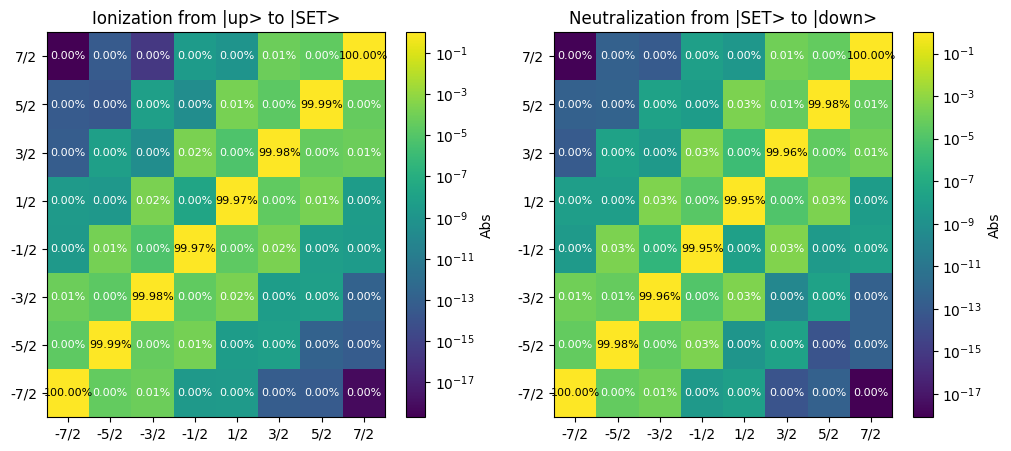

In [56]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

title_ionize = 'Ionization from |up> to |SET>'
plot_transition_matrix(transition_matrix_ionize_up, ax=ax[0], electron_states=1, title=title_ionize)
title_neutralize = 'Neutralization from |SET> to |down>'
plot_transition_matrix(transition_matrix_neutralize_down, ax=ax[1], electron_states=1, title=title_neutralize)

In [57]:
transition_matrix_ionize_up

array([[9.99903095e-01, 3.47955973e-05, 6.21026280e-05, 2.27895615e-09,
        2.79751689e-09, 6.08437079e-14, 4.28513382e-14, 6.62774148e-19],
       [2.49434334e-05, 9.99804534e-01, 3.66662947e-05, 1.33846771e-04,
        3.41286367e-09, 6.07685098e-09, 1.29592512e-13, 4.38906715e-14],
       [6.18755133e-05, 1.97093365e-05, 9.99710642e-01, 2.81433163e-05,
        1.79617351e-04, 4.09801826e-09, 6.16963248e-09, 1.28183957e-13],
       [2.21416687e-09, 1.33668019e-04, 6.52950396e-06, 9.99655488e-01,
        2.33884277e-05, 1.80915612e-04, 5.02384977e-09, 2.92812785e-09],
       [2.76622901e-09, 1.84039256e-09, 1.79607879e-04, 2.14777046e-08,
        9.99655781e-01, 2.76449038e-05, 1.36779016e-04, 3.82721202e-09],
       [5.91616191e-14, 6.02188196e-09, 2.40027355e-10, 1.80926047e-04,
        5.93616489e-06, 9.99711419e-01, 3.73095450e-05, 6.44023183e-05],
       [4.16779976e-14, 2.34314971e-14, 6.11265906e-09, 2.58723898e-10,
        1.36623826e-04, 2.00126114e-05, 9.99806216e-01, 3.

In [58]:
np.save(r'sims_data/neutralization_down_matrix.npy', np.abs(transition_matrix_neutralize_down))
np.save(r'sims_data/ionization_up_matrix.npy', np.abs(transition_matrix_ionize_up))

<Axes: title={'center': 'Estimated transition matrix through direct projection'}>

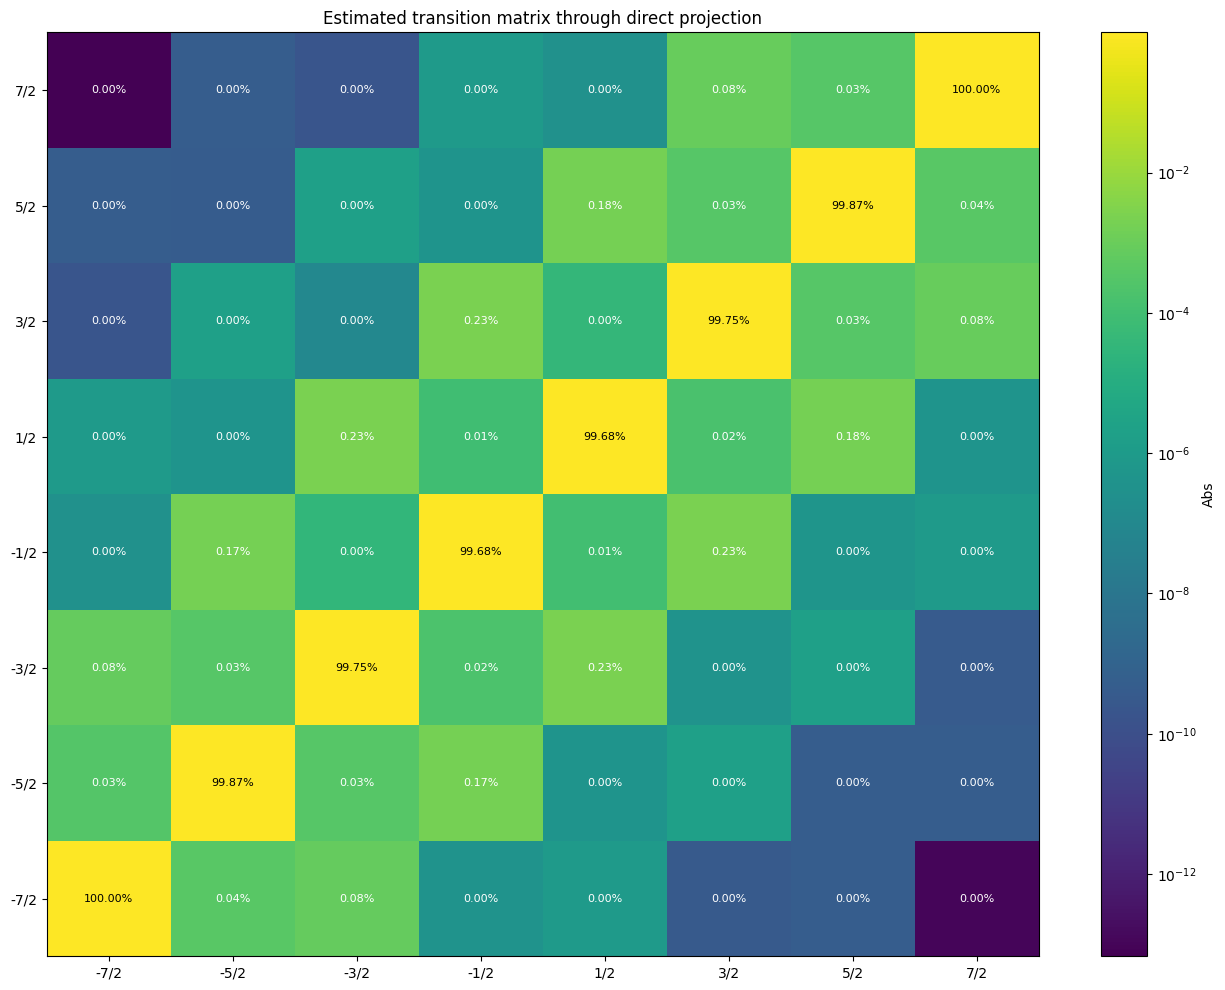

In [59]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
n_tunnel = 4.47
T_est = fractional_matrix_power(np.abs(transition_matrix_neutralize_down) @ np.abs(transition_matrix_ionize_up), n_tunnel)

plot_transition_matrix(T_est, electron_states=1, ax=ax, title='Estimated transition matrix through direct projection')

In [60]:
np.save(r'sims_data/ionization_matrix_proj.npy', T_est)